<a href="https://colab.research.google.com/github/Sherlysukmadira/2311532015_Sherly-Sukmadira-Putri_ImageProcessing/blob/main/Prediksijantung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('/content/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Terdapat 13 fitur dan 1 target

/tmp/ipykernel_6183/1776004172.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="bwr")


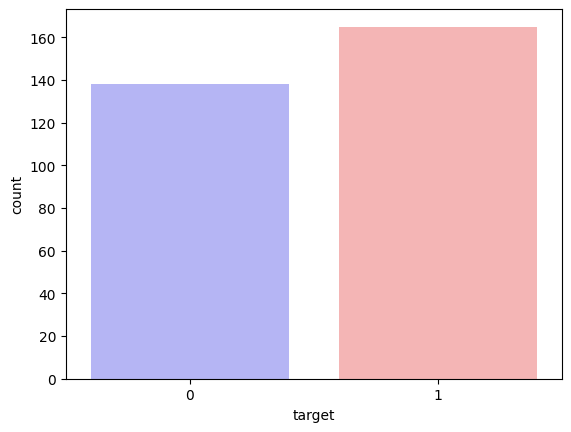

In [3]:
df.target.value_counts()
sns.countplot(x="target", data=df, palette="bwr")
plt.show()

Analisis :
Data set tergolong seimbang meskipun ada sedikit selisih antara jumlah pasien yang tidak terkena serangan jantung (target = 0) dan yang terkena penyakit jantung (target = 1)

In [ ]:
countNoDisease = len(df[df.target == 0])
countHaveDisease = len(df[df.target == 1])
print("Persentase pasien tidak memiliki penyakit jantung: {:.2f}%".format((countNoDisease / (len(df.target))*100)))
print("Persentasi pasien memiliki penyakit jantung: {:.2f}%".format((countHaveDisease / (len(df.target))*100)))

Persentase pasien tidak memiliki penyakit jantung: 45.54%
Persentasi pasien memiliki penyakit jantung: 54.46%


<ipython-input-5-52434e4e9aaa>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette="mako_r")


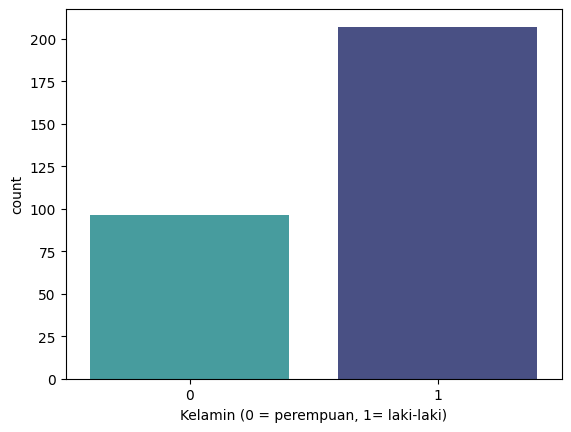

In [ ]:
sns.countplot(x='sex', data=df, palette="mako_r")
plt.xlabel("Kelamin (0 = perempuan, 1= laki-laki)")
plt.show()

Analisis : Pada data ini terdapat imbalance antara jumlah perempuan dan laki-laki

In [4]:
countFemale = len(df[df.sex == 0])
countMale = len(df[df.sex == 1])
print("Persentase pasien perempuan: {:.2f}%".format((countFemale / (len(df.sex))*100)))
print("Persentase pasien laki-laki: {:.2f}%".format((countMale / (len(df.sex))*100)))

Persentase pasien perempuan: 31.68%
Persentase pasien laki-laki: 68.32%


In [5]:
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478
1,52.496970,0.563636,1.375758,129.303030,242.230303,0.139394,0.593939,158.466667,0.139394,0.583030,1.593939,0.363636,2.121212


Analisis :

Target bernilai 1 (sakit jantung) rata-rata memiliki ciri berikut :
1. age lebih muda (52 vs 56)
2. thalach lebih tinggi (158 vs 139)
3. cholesterol sedikit lebih rendah
4. oldpeak lebih rendah
5. exang jauh lebih rendah (0.13 vs 0.55)
6. cp (chest pain) lebih tinggi


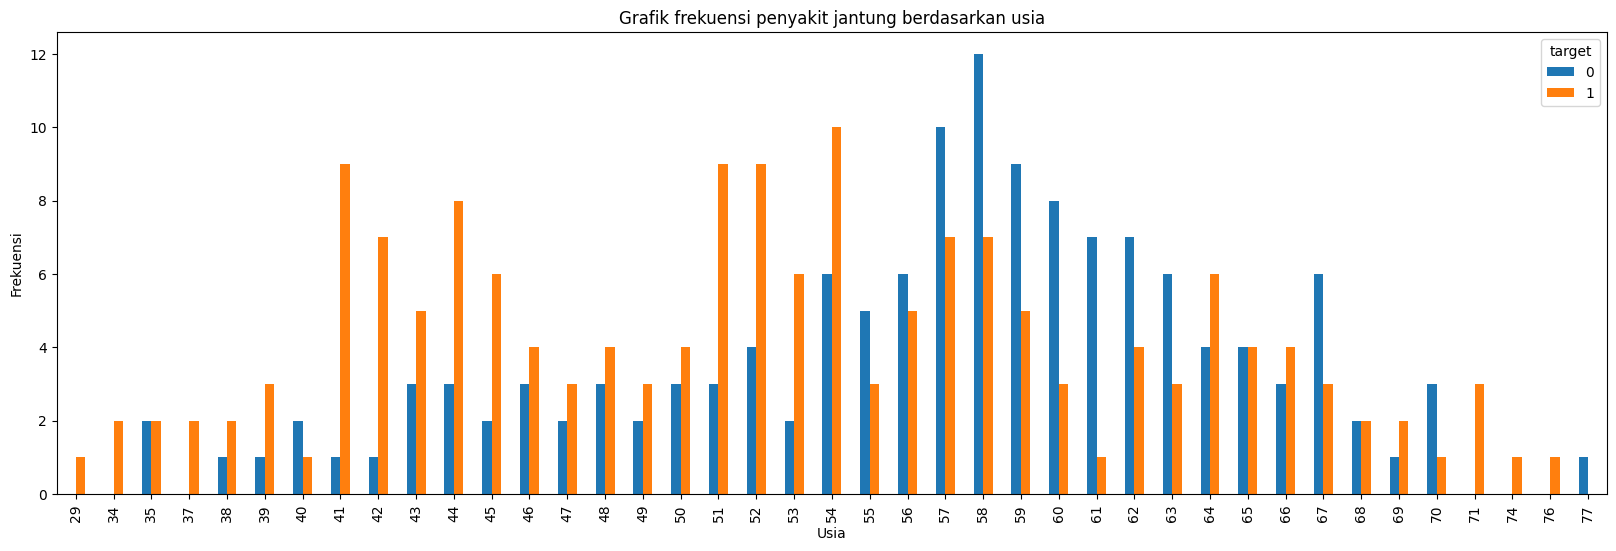

In [6]:
pd.crosstab(df.age,df.target).plot(kind="bar",figsize=(20,6))
plt.title('Grafik frekuensi penyakit jantung berdasarkan usia')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.savefig('PenyakitJantungDanUmur.png')
plt.show()

Usia 57 tahun adalah usia yang paling banyak terkena penyakit jantung

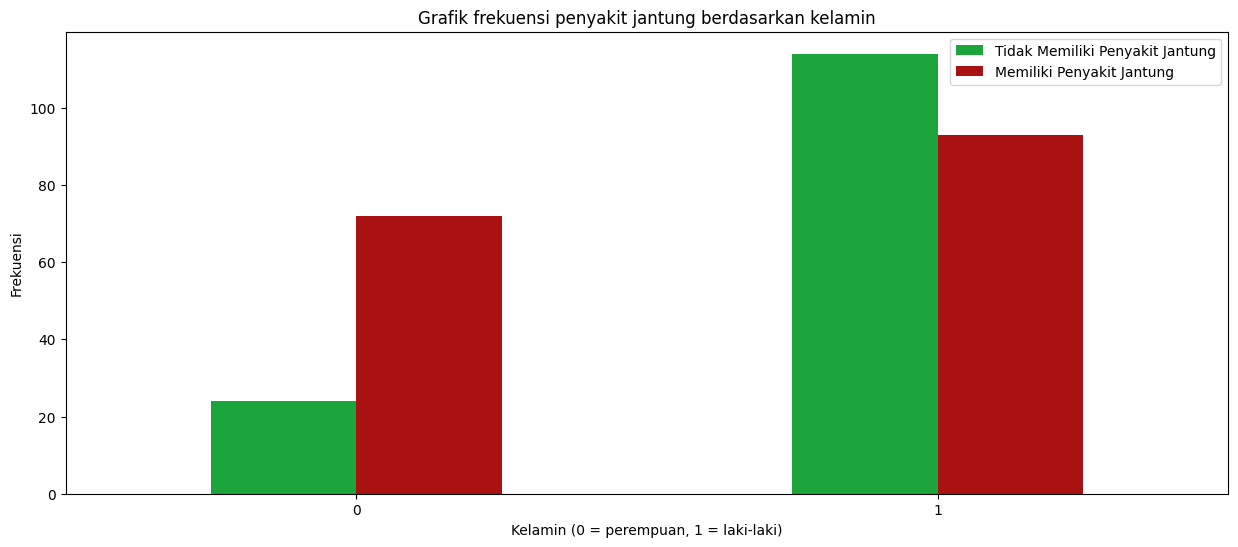

In [7]:
pd.crosstab(df.sex,df.target).plot(kind="bar",figsize=(15,6),color=['#1CA53B','#AA1111' ])
plt.title('Grafik frekuensi penyakit jantung berdasarkan kelamin')
plt.xlabel('Kelamin (0 = perempuan, 1 = laki-laki)')
plt.xticks(rotation=0)
plt.legend(["Tidak Memiliki Penyakit Jantung", "Memiliki Penyakit Jantung"])
plt.ylabel('Frekuensi')
plt.show()

laki-laki lebih cendrung terkena penyakit jantung

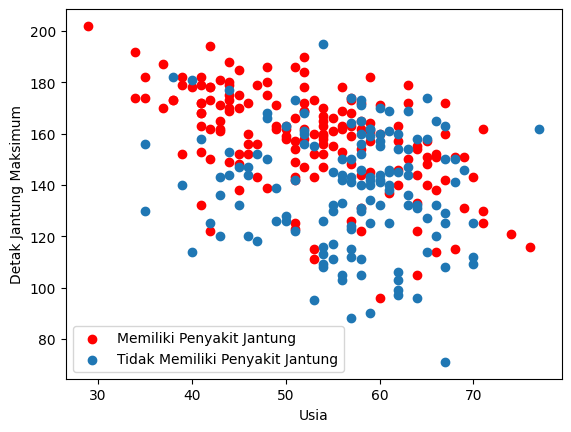

In [8]:
plt.scatter(x=df.age[df.target==1], y=df.thalach[(df.target==1)], c="red")
plt.scatter(x=df.age[df.target==0], y=df.thalach[(df.target==0)])
plt.legend(["Memiliki Penyakit Jantung", "Tidak Memiliki Penyakit Jantung"])
plt.xlabel("Usia")
plt.ylabel("Detak Jantung Maksimum")
plt.show()

Semakin tinggi detak jantung semakin berpotensi seseorang terkena penyakit jantung

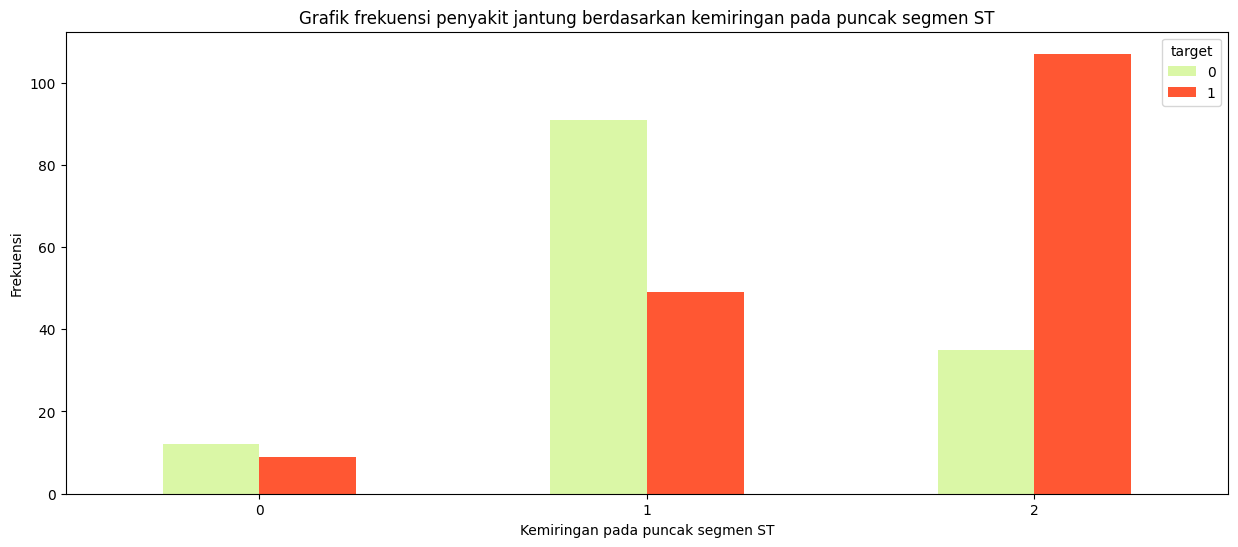

In [9]:
pd.crosstab(df.slope,df.target).plot(kind="bar",figsize=(15,6),color=['#DAF7A6','#FF5733' ])
plt.title('Grafik frekuensi penyakit jantung berdasarkan kemiringan pada puncak segmen ST')
plt.xlabel('Kemiringan pada puncak segmen ST')
plt.xticks(rotation = 0)
plt.ylabel('Frekuensi')
plt.show()

Fitur slope memiliki korelasi positif yang kuat dengan target. Pasien dengan nilai SLope 2 memiliki resiko tertinggi terkena penyakit jantung dibandingkan kategori lainnya.

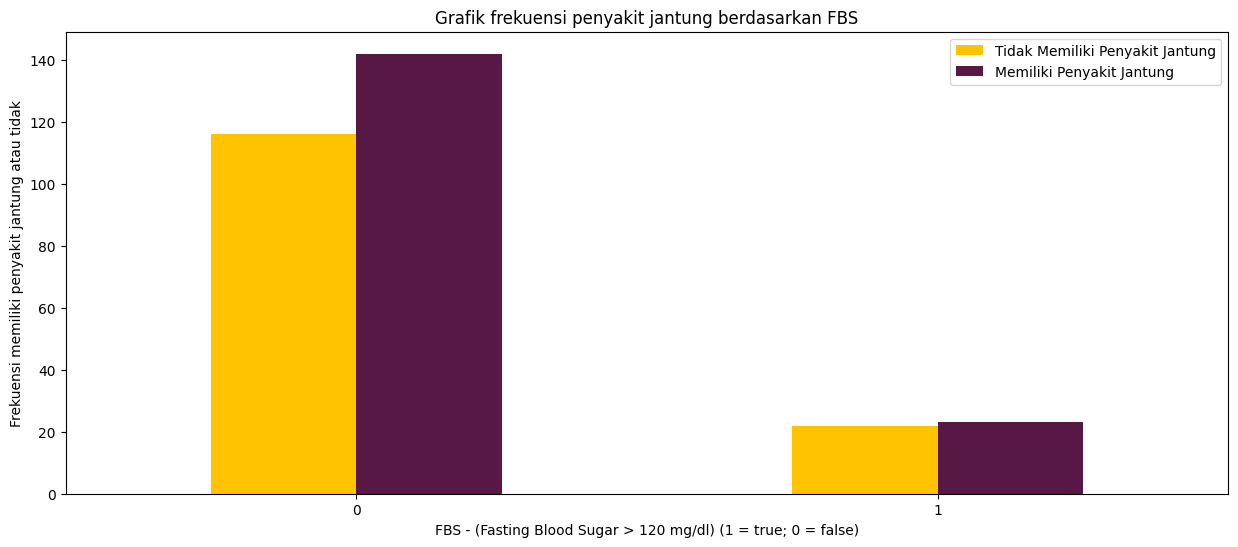

In [10]:
pd.crosstab(df.fbs,df.target).plot(kind="bar",figsize=(15,6),color=['#FFC300','#581845' ])
plt.title('Grafik frekuensi penyakit jantung berdasarkan FBS')
plt.xlabel('FBS - (Fasting Blood Sugar > 120 mg/dl) (1 = true; 0 = false)')
plt.xticks(rotation = 0)
plt.legend(["Tidak Memiliki Penyakit Jantung", "Memiliki Penyakit Jantung"])
plt.ylabel('Frekuensi memiliki penyakit jantung atau tidak')
plt.show()

Analisis :
FBS adalah tes gula darah puasa. Pada grafik di atas mayoritas pasien yang terkena penyakit jantung ialah pasien yang memiliki gula darah di bawah 120 mg/dl. Hal ini mengindikasikan bahwa FBS bukan merupakan pembeda tunggal yang kuat untuk memprediksi penyakit jantung dalam dataset ini. Seseorang dengan gula darah normal (0) tetap memiliki risiko tinggi terkena penyakit jantung.

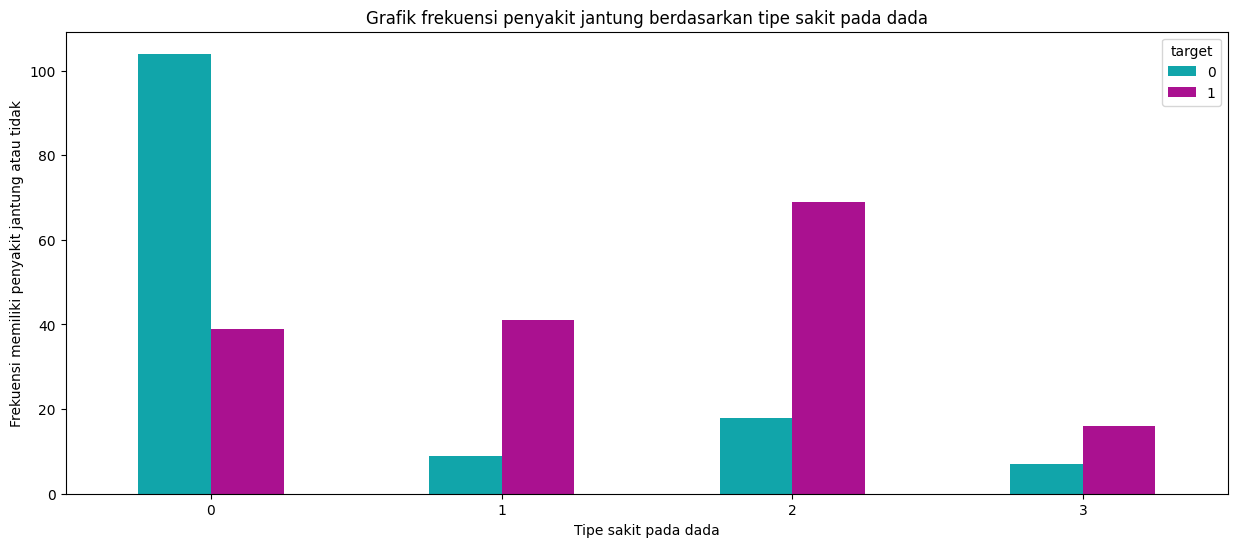

In [11]:
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(15,6),color=['#11A5AA','#AA1190' ])
plt.title('Grafik frekuensi penyakit jantung berdasarkan tipe sakit pada dada')
plt.xlabel('Tipe sakit pada dada')
plt.xticks(rotation = 0)
plt.ylabel('Frekuensi memiliki penyakit jantung atau tidak')
plt.show()

Analisis :
Mayoritas pasien dengan penyakit jantung banyak memiliki tipe sakit dada 2. Sehingga pasien dengan  tipe 2 berpotensi besar terkena penyakit jantung

In [12]:
scaler = MinMaxScaler()

normalized_array = scaler.fit_transform(df[['sex','chol','fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']])
normalized_df = pd.DataFrame(normalized_array, columns=['sex','chol','fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'])

df[['sex','chol','fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']] = normalized_df

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1.0,3,145,0.244292,1.0,0.0,150,0.0,2.3,0.0,0.0,0.333333,1
1,37,1.0,2,130,0.283105,0.0,0.5,187,0.0,3.5,0.0,0.0,0.666667,1
2,41,0.0,1,130,0.178082,0.0,0.0,172,0.0,1.4,1.0,0.0,0.666667,1
3,56,1.0,1,120,0.251142,0.0,0.5,178,0.0,0.8,1.0,0.0,0.666667,1
4,57,0.0,0,120,0.520548,0.0,0.5,163,1.0,0.6,1.0,0.0,0.666667,1


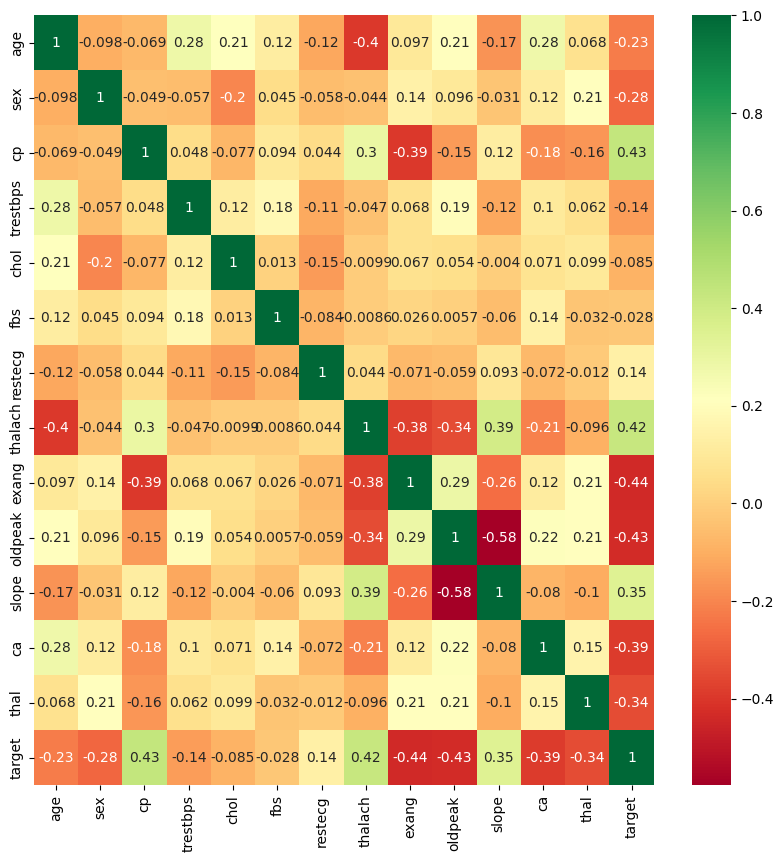

In [14]:
correlations = df.corr()
plt.figure(figsize=(10, 10))

heatmap_heart = sns.heatmap(df[correlations.index].corr(), annot=True, cmap='RdYlGn')

plt.show()

Cp, Thalach, dan slope memiliki pengaruuh yang kuat terhadap target (klasifikasi terkena penyakit jantung/ tidak)

In [15]:
X = df.drop(['target'], axis = 1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [16]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

In [17]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

cnf_matrix

array([[22,  5],
       [ 9, 25]])

In [18]:
print("Accuracy: ", metrics.accuracy_score(y_test, y_pred))
print("Precision: ", metrics.precision_score(y_test, y_pred))
print("Recall/Sensitivity: ", metrics.recall_score(y_test, y_pred))

Accuracy:  0.7704918032786885
Precision:  0.8333333333333334
Recall/Sensitivity:  0.7352941176470589


In [19]:
smote = SMOTE(random_state = 45)

s_X_train, s_y_train =smote.fit_resample(X_train,y_train)
s_X_test, s_y_test = smote.fit_resample(X_test,y_test)

In [20]:
s_dt = DecisionTreeClassifier()

s_dt.fit(s_X_train, s_y_train)

s_y_pred = dt.predict(s_X_test)

In [21]:
s_cnf_matrix = metrics.confusion_matrix(s_y_test, s_y_pred)

s_cnf_matrix

array([[27,  7],
       [ 9, 25]])

In [22]:
print("Accuracy: ", metrics.accuracy_score(s_y_test, s_y_pred))
print("Precision: ", metrics.precision_score(s_y_test, s_y_pred))
print("Recall/Sensitivity: ", metrics.recall_score(s_y_test, s_y_pred))

Accuracy:  0.7647058823529411
Precision:  0.78125
Recall/Sensitivity:  0.7352941176470589
